# Track Visualization for one structure

This notebook reads track outputs generated by `esm3di/tracks.py` (aa, plddt_bin, contact_bin, range_bin, burial_bin, bend_bin, torsion_bin) and plots representative per-residue tracks for one selected entry chain ID.


In [33]:
import py3Dmol

def show_colored_pdb(pdb_path, colors):
	"""
	Visualize a PDB file with per-residue discrete colors using py3dmol.

	Args:
		pdb_path (str): Path to the PDB file.
		colors (list or array): List of color hex strings or color names, one per residue.
	"""
	with open(pdb_path) as f:
		pdb_data = f.read()

	view = py3Dmol.view(width=600, height=400)
	view.addModel(pdb_data, "pdb")
	view.setStyle({'cartoon': {}})

	for i, color in enumerate(colors, start=1):
		view.setStyle({'resi': str(i)}, {'cartoon': {'color': color}})

	view.zoomTo()
	return view

# Example usage:
# colors = ['red', 'blue', 'green', ...]  # length = number of residues
# show_colored_pdb('example.pdb', colors)

In [34]:
%%bash 
pwd
head -n 10 AF-P0CG47-F1-model_v4.pdb

/home/dmoi/projects/ESM3di/notebooks
<?xml version='1.0' encoding='UTF-8'?><Error><Code>NoSuchKey</Code><Message>The specified key does not exist.</Message></Error>

In [42]:
#use autoreload to reflect changes in tracks.py without restarting the notebook
%load_ext autoreload
%autoreload 2

from esm3di.tracks import process_one
import requests
from pathlib import Path
import numpy as np
from esm3di import tracks

# Download an example PDB (AlphaFold 1UBQ)

pdb_path = Path("../flavi_redo/Single_Chain_RSCB_PDB_References/FJMB_E_6ZQI_A.pdb")

# Extract tracks for the first chain
tables = tracks.process_one(path_str=str(pdb_path))
discretized_vector = []
for table in tables:
	table = ''.join(table.split('\n')[1:]).strip()
	vals = list(set([ c for c in table]))
	discretized = [ vals.index(x) for x in [c for c in table] ]
	discretized_vector.append(discretized)
discretized_vector = np.array(discretized_vector)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


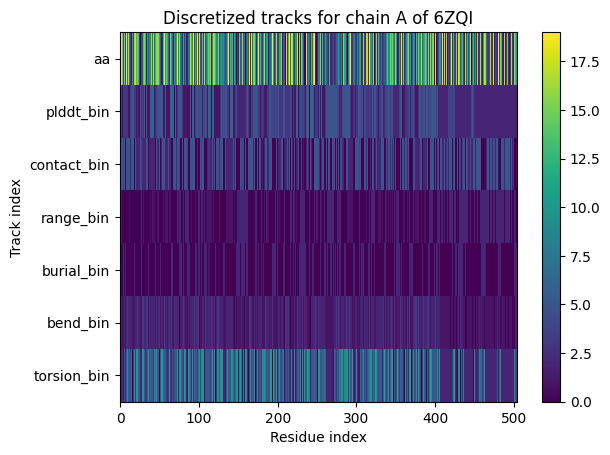

In [50]:
from matplotlib import pyplot as plt
#dont smooth the image, we want to see the discrete values clearly
plt.imshow(discretized_vector, aspect='auto' ,  interpolation='none')
plt.colorbar()
plt.title("Discretized tracks for chain A of 6ZQI")
plt.xlabel("Residue index")
plt.ylabel("Track index")
track_names = [
    "aa", "plddt_bin", "contact_bin", "range_bin", "burial_bin", "bend_bin", "torsion_bin"
]
plt.yticks(ticks=np.arange(len(track_names)), labels=track_names)

plt.show()
# Set y-tick labels to the track names in order


In [49]:
#create a list of colors 
import colour
n = 20 # number of discrete values in the track
red = colour.Color("red")
colors = list(red.range_to(colour.Color("blue"), n))
colors = [c.hex for c in colors]

# Visualize the PDB with the first track's colors
pdb_colors = [colors[val] for val in discretized_vector[2]]  # use the first track for coloring
show_colored_pdb(str(pdb_path), pdb_colors)

3Dmol.js failed to load for some reason. Please check your browser console for error messages.